Importing SPACY

In [24]:
import spacy
from spacy.pipeline import EntityRuler
from spacy.lang.en import English
from spacy.tokens import Doc

#gensim
import gensim
from gensim import corpora

#visualizations
from spacy import displacy
import pyLDAvis.gensim_models
from wordcloud import WordCloud
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

#Data Loading/ Data manipulation
import pandas as pd
import numpy as np
import jsonlines

#nltk
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
nltk.download(['stopwords','wordnet'])

#warning
import warnings
warnings.filterwarnings('ignore')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\vinee\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\vinee\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Loading the dataset

In [2]:
df = pd.read_csv(r"C:\Users\vinee\OneDrive\Desktop\projects\Resume_analysis\Resume\Resume.csv")
df = df.reindex(np.random.permutation(df.index))
data = df.copy().iloc[0:200]
data.head()

,ID,Resume_str,Resume_html,Category
481,20400279,CUSTOMER SERVICE ADVOCATE P...,"<div class=""fontsize fontface vmargins hmargin...",ADVOCATE
1287,40311088,MEDIA SPECIALIST II Professiona...,"<div class=""fontsize fontface vmargins hmargin...",DIGITAL-MEDIA
1475,11877150,FINANCE Professional Summar...,"<div class=""fontsize fontface vmargins hmargin...",FINANCE
1247,15484097,25LIVE FUNCTIONAL ADMINISTRATOR/SUP...,"<div class=""fontsize fontface vmargins hmargin...",DIGITAL-MEDIA
1279,18488289,SENIOR DIGITAL MARKETING SPECIALIST ...,"<div class=""fontsize fontface vmargins hmargin...",DIGITAL-MEDIA


SPACY model


In [9]:
nlp = spacy.load("en_core_web_lg")
skill_pattern_path = 'jz_skill_patterns.jsonl'

Entity Ruler

In [10]:
ruler = nlp.add_pipe('entity_ruler')
ruler.from_disk(skill_pattern_path)
nlp.pipe_names

['tok2vec',
 'tagger',
 'parser',
 'attribute_ruler',
 'lemmatizer',
 'ner',
 'entity_ruler']

In [11]:
def get_skills(text):
    doc = nlp(text)
    myset = []
    subset = []
    for ent in doc.ents:
        if ent.label_ == 'SKILL':
            subset.append(ent.text)
    myset.append(subset)
    return subset

def unique_skills(x):
    return list(set(x))

Cleaning Resume Text


In [13]:
clean = []
for i in range(data.shape[0]):
    review = re.sub(
        '(@[A-Za-z0-9]+)|([^0-9A-Za-z \t])|(\w+:\/\/\S+)|^rt|http.+?"', " ", data["Resume_str"].iloc[i]
    )
    review = review.lower()
    review = review.split()
    lm = WordNetLemmatizer()
    review = [
        lm.lemmatize(word)
        for word in review
        if not word in set(stopwords.words("english"))
    ]
    review = " ".join(review)
    clean.append(review)

In [14]:
data['clean_resume'] = clean
data['skills'] = data['clean_resume'].str.lower().apply(get_skills)
data['skills'] = data['skills'].apply(unique_skills)
data.head()

,ID,Resume_str,Resume_html,Category,clean_resume,skills
481,20400279,CUSTOMER SERVICE ADVOCATE P...,"<div class=""fontsize fontface vmargins hmargin...",ADVOCATE,customer service advocate professional summary...,"[business, design, interaction, schedule]"
1287,40311088,MEDIA SPECIALIST II Professiona...,"<div class=""fontsize fontface vmargins hmargin...",DIGITAL-MEDIA,medium specialist ii professional summary want...,"[schedule, design, computer science, marketing..."
1475,11877150,FINANCE Professional Summar...,"<div class=""fontsize fontface vmargins hmargin...",FINANCE,finance professional summary versatile highly ...,"[marketing, finance, accounting, business]"
1247,15484097,25LIVE FUNCTIONAL ADMINISTRATOR/SUP...,"<div class=""fontsize fontface vmargins hmargin...",DIGITAL-MEDIA,25live functional administrator supervisor hel...,"[schedule, help desk, support, design, release..."
1279,18488289,SENIOR DIGITAL MARKETING SPECIALIST ...,"<div class=""fontsize fontface vmargins hmargin...",DIGITAL-MEDIA,senior digital marketing specialist summary di...,"[material, twitter, search engine, database, s..."


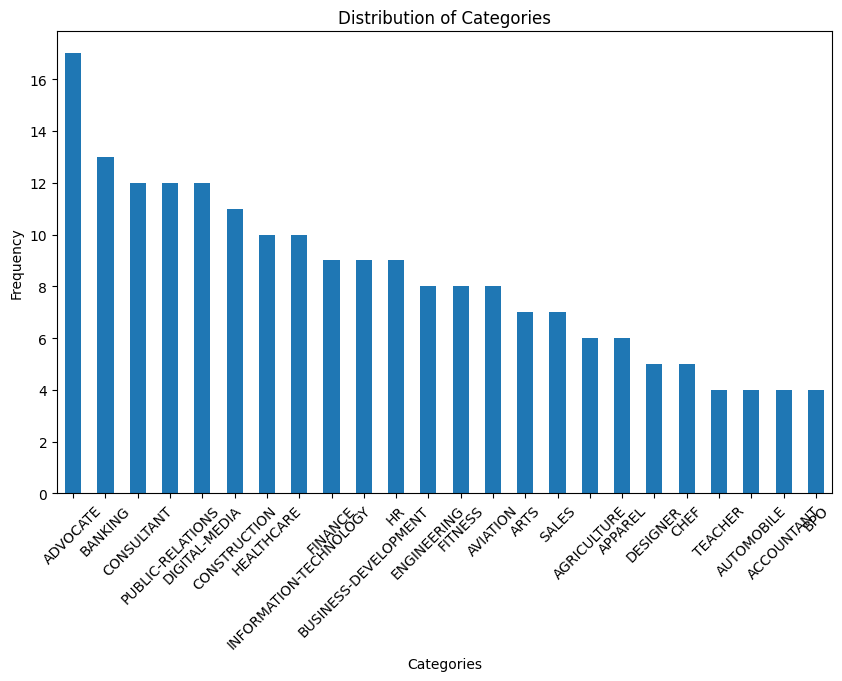

In [19]:
plt.figure(figsize=(10, 6))
data['Category'].value_counts().plot(kind='bar')
plt.title("Distribution of Categories")
plt.xlabel("Categories")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.show()


In [21]:
job_cat = data['Category'].unique()
job_cat = np.append(job_cat,"ALL")

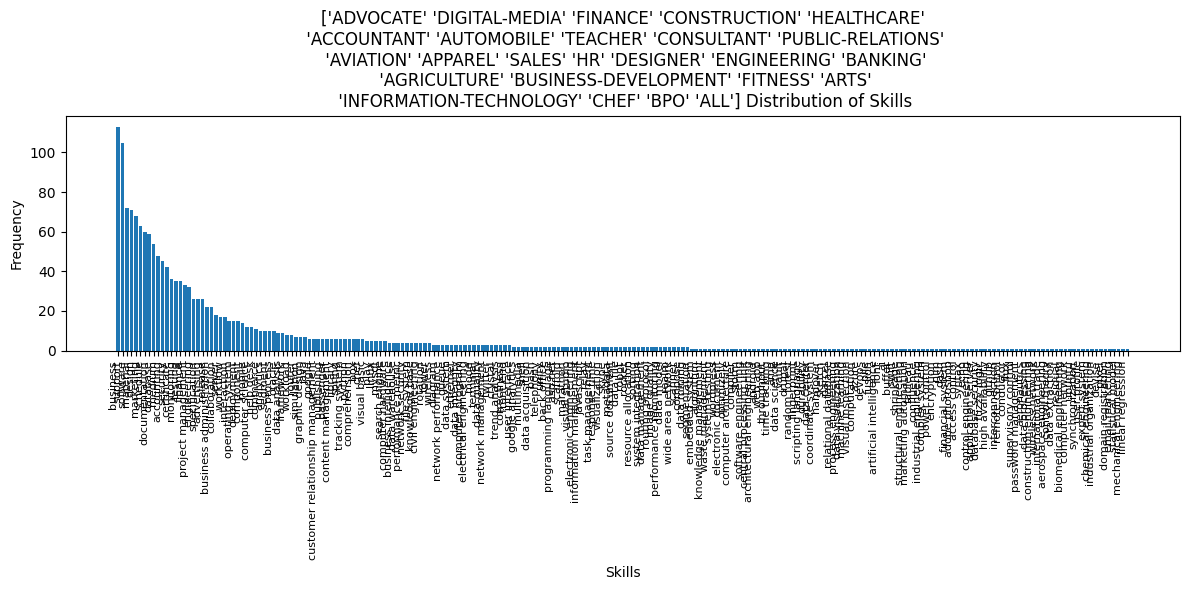

In [44]:
Job_Category = 'BUSINESS-DEVELOPMENT'
Total_skills = []
if "ALL" not in job_cat:
    fltr = data[data["Category"] == Job_Category]["skills"]
    for x in fltr:
        for i in X:
            Total_skills.append(i)
else:
    fltr = data['skills']
    for x in fltr:
        for i in x:
            Total_skills.append(i)


# Convert Total_skills to a pandas Series if it's a list
Total_skills_series = pd.Series(Total_skills)

# Count the frequency of each skill
skill_counts = Total_skills_series.value_counts()

# Sort skills in descending order by frequency
sorted_skills = skill_counts.sort_values(ascending=False)

# Plotting
plt.figure(figsize=(12,6))
plt.bar(sorted_skills.index, sorted_skills.values)

# Adding labels and title
plt.xlabel("Skills")
plt.ylabel("Frequency")
plt.title(f"{job_cat} Distribution of Skills")
plt.xticks(rotation=90, ha="right", fontsize =8)

# Show the plot
plt.tight_layout()
plt.show()

Text(0.5, 1.0, "Most Used Words in ['ADVOCATE' 'DIGITAL-MEDIA' 'FINANCE' 'CONSTRUCTION' 'HEALTHCARE'\n 'ACCOUNTANT' 'AUTOMOBILE' 'TEACHER' 'CONSULTANT' 'PUBLIC-RELATIONS'\n 'AVIATION' 'APPAREL' 'SALES' 'HR' 'DESIGNER' 'ENGINEERING' 'BANKING'\n 'AGRICULTURE' 'BUSINESS-DEVELOPMENT' 'FITNESS' 'ARTS'\n 'INFORMATION-TECHNOLOGY' 'CHEF' 'BPO' 'ALL'] Resume")

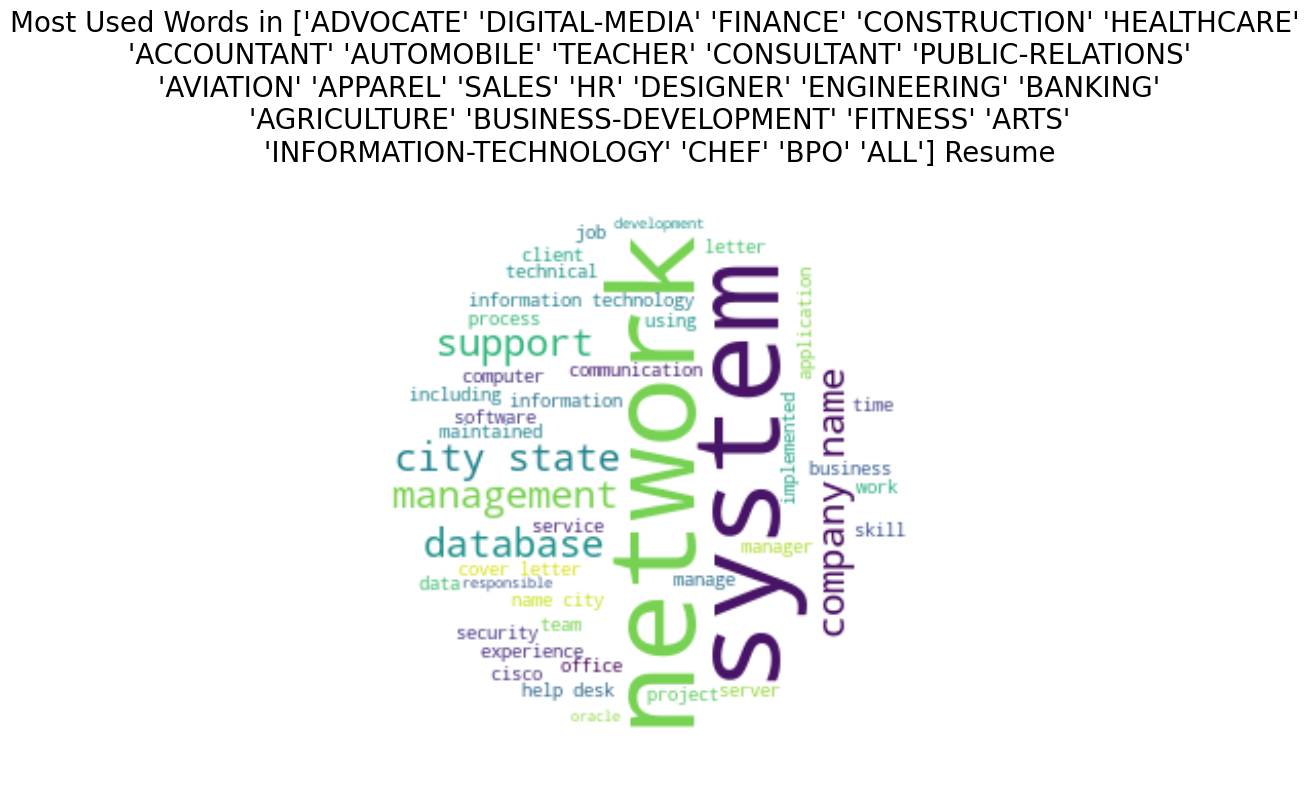

In [47]:
Job_Category = "INFORMATION-TECHNOLOGY"
text = ""
for i in data[data["Category"] == Job_Category]["clean_resume"].values:
    text += i + " "

plt.figure(figsize=(8, 8))

x, y = np.ogrid[:300, :300]

mask = (x - 150) ** 2 + (y - 150) ** 2 > 130 ** 2
mask = 255 * mask.astype(int)

wc = WordCloud(
    width=800,
    height=800,
    background_color="white",
    min_font_size=6,
    repeat=True,
    mask=mask,
)
wc.generate(text)

plt.axis("off")
plt.imshow(wc, interpolation="bilinear")
plt.title(f"Most Used Words in {job_cat} Resume", fontsize=20)

In [49]:
sent = nlp(data['Resume_str'].iloc[1])
displacy.render(sent, style='ent', jupyter=True)

In [50]:
displacy.render(sent[0:10], style='dep', jupyter=True, options={'distance':90})

In [51]:
patterns = df.Category.unique()
for a in patterns:
    ruler.add_patterns([{"label": "Job-Category","pattern": a}])

In [53]:
colors = {
    "Job-Category": "linear-gradient(90deg, #aa9cfc, #fc9ce7)",
    "SKILL": "linear-gradient(90deg, #9BE15D, #00E3AE)",
    "ORG": "#ffd966",
    "PERSON": "#e06666",
    "GPE": "#9fc5e8",
    "DATE": "#c27ba0",
    "ORDINAL": "#674ea7",
    "PRODUCT": "#f9cb9c",
}
options = {
    "ents": [
        "Job-Category",
        "SKILL",
        "ORG",
        "PERSON",
        "GPE",
        "DATE",
        "ORDINAL",
        "PRODUCT",
    ],
    "colors": colors,
}
sent = nlp(data['Resume_str'].iloc[6])
displacy.render(sent, style='ent', jupyter=True, options=options)